# pymodal — Dimensional collections, references, and typed indicators

A didactic tour of the **post-refactor architecture**. No model training here —
that lives in the companion `demo.ipynb`. This notebook walks through:

1. The four dimensional parents (0-D / 1-D / 2-D / 3-D) and what unites them.
2. Building a 1-D `frf` collection — single-array vs multi-array constructors.
3. Inside the HDF5 file: items, axes, channel metadata.
4. **Reference linking** (embed-by-copy): how a derived collection carries its
   sources around with it, and survives even if those sources are deleted.
5. Producer-driven references: `timeseries.to_FRF` auto-registers
   `{"input": excitation, "output": response}`.
6. Typed indicators — 2-D matrices (CFDAC/FDAC), 1-D vectors (RVAC/GAC),
   0-D scalars (SCI/DRQ/...). Same factory pattern, different dimensionality.
7. Provenance round-trip — recover any item's source FRFs from the
   indicator collection alone.
8. PyTorch handoff with variable-rank items.

In [1]:
# ── Install pymodal at the head of the master branch (Colab-friendly) ──
import sys, subprocess

_needs_install = True
try:
    import pymodal
    if getattr(pymodal, "__version__", "0") >= "0.2.0":
        _needs_install = False
except Exception:
    pass

if _needs_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "pyFRF>=0.40", "pint>=0.20.1", "audiomentations>=0.31.0",
                           "h5py", "numpy", "matplotlib"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "--no-deps", "--force-reinstall", "--no-cache-dir",
                           "git+https://github.com/grcarmenaty/pymodal.git@master"])
    import IPython
    IPython.Application.instance().kernel.do_shutdown(restart=True)
else:
    print("pymodal", pymodal.__version__, "already installed.")

pymodal 0.2.0 already installed.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import pymodal
print(f"pymodal version: {pymodal.__version__}")

pymodal version: 0.2.0


## 1 · The dimensional hierarchy

Every collection in pymodal subclasses one of four dimensional parents.
The number of **functional domain axes** is fixed at the class level and
determines the rank of every item array:

| Parent | `_n_domain_axes` | Item shape | Used by |
|---|---|---|---|
| `_collection_0d` | 0 | `(n_outputs, n_inputs)` | `sci_collection`, `drq_collection`, … |
| `_collection_1d` | 1 | `(D1, n_outputs, n_inputs)` | `frf`, `timeseries`, `rvac_collection`, `gac_collection` |
| `_collection_2d` | 2 | `(D1, D2, n_outputs, n_inputs)` | `cfdac_collection`, `fdac_collection` |
| `_collection_3d` | 3 | `(D1, D2, D3, n_outputs, n_inputs)` | reserved (e.g. time-resolved CFDAC) |

Channel/DOF metadata (`(n_outputs, n_inputs)`) is **always** preserved as the
trailing two axes — irrespective of dimensionality.

In [3]:
print("Dimensional parents and their item-shape contract:")
for cls in (pymodal._collection_0d, pymodal._collection_1d,
            pymodal._collection_2d, pymodal._collection_3d):
    print(f"  {cls.__name__:18s}  _n_domain_axes={cls._n_domain_axes}  "
          f"→ item rank = {cls._n_domain_axes + 2}")

Dimensional parents and their item-shape contract:
  _collection_0d      _n_domain_axes=0  → item rank = 2
  _collection_1d      _n_domain_axes=1  → item rank = 3
  _collection_2d      _n_domain_axes=2  → item rank = 4
  _collection_3d      _n_domain_axes=3  → item rank = 5


## 2 · Building a 1-D `frf` collection

`frf` is a thin subclass of `_collection_1d` whose single domain axis is
frequency. The constructor takes either a single ndarray (1-item collection)
or a list of ndarrays (multi-item) — there is no separate `frf_collection`
class anymore.

In [4]:
WORK = Path("./_pymodal_arch_demo"); WORK.mkdir(exist_ok=True)
RNG = np.random.default_rng(0)

def synthetic_frf(n_freq=64, n_outputs=4, n_inputs=1, scale=1.0):
    """A toy complex FRF for didactic purposes."""
    return scale * (RNG.standard_normal((n_freq, n_outputs, n_inputs))
                    + 1j * RNG.standard_normal((n_freq, n_outputs, n_inputs))
                    ).astype(np.complex64)

# Single-array constructor → 1-item collection
single = pymodal.frf(
    measurements=synthetic_frf(),
    freq_resolution=1.0, freq_units="hertz",
    method="SIMO", name="solo",
    path=WORK / "single.h5",
)
print(f"len(single)              : {len(single)}")
print(f"single.measurements[0]   : {single.measurements[0].shape}  (n_freq, n_outputs, n_inputs)")
print(f"single.channel_shape()   : {single.channel_shape()}")
print(f"single.domain_shape()    : {single.domain_shape()}")

len(single)              : 1
single.measurements[0]   : (64, 4, 1)  (n_freq, n_outputs, n_inputs)
single.channel_shape()   : (4, 1)
single.domain_shape()    : (64,)


In [5]:
# List-of-arrays constructor → multi-item collection
many = pymodal.frf(
    measurements=[synthetic_frf(scale=s) for s in (1.0, 0.9, 1.1)],
    freq_resolution=1.0, freq_units="hertz",
    method="SIMO",
    names=["healthy", "cracked", "loose"],
    labels=[0, 1, 2],
    path=WORK / "many.h5",
)
print(f"len(many)                : {len(many)}")
print(f"many.name                : {many.name}")
print(f"many.measurements[1].shape: {many.measurements[1].shape}  (item 1)")
print(f"many.labels[2][()]       : {many.labels[2][()]}")
# Channel/DOF metadata is generated even when not provided
print(f"many.coordinates.shape   : {many.coordinates.shape}  ((dof, 3))")

len(many)                : 3
many.name                : ['healthy', 'cracked', 'loose']
many.measurements[1].shape: (64, 4, 1)  (item 1)
many.labels[2][()]       : 2
many.coordinates.shape   : (4, 3)  ((dof, 3))


## 3 · Inside the HDF5 file

Every collection is backed by an HDF5 file. The layout is the same regardless
of dimensionality, so a generic reader (and `HDF5Dataset`) can handle 0-D / 1-D
/ 2-D collections uniformly.

In [6]:
with h5py.File(many.path, "r") as f:
    print("/measurements/.attrs")
    for k, v in f["measurements"].attrs.items():
        print(f"  {k:20s} {v}")
    print("\n/measurements/_axes/  (one dataset per domain axis)")
    for name, ds in f["measurements/_axes"].items():
        print(f"  {name}/data shape={ds.shape}  units={ds.attrs['units']}")
    print("\n/measurements/{name}/  (one group per item)")
    for name in many.name:
        print(f"  {name}/data shape={f[f'measurements/{name}/data'].shape}")

/measurements/.attrs
  coordinates          [[0. 0. 0.]
 [1. 0. 0.]
 [2. 0. 0.]
 [3. 0. 0.]]
  dof                  4
  measurements_units   millimeter / second ** 2 / newton
  method               SIMO
  n_domain_axes        1
  n_inputs             1
  n_outputs            4
  orientations         [[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
  space_units          millimeter

/measurements/_axes/  (one dataset per domain axis)
  axis_0/data shape=(64,)  units=hertz

/measurements/{name}/  (one group per item)
  healthy/data shape=(64, 4, 1)
  cracked/data shape=(64, 4, 1)
  loose/data shape=(64, 4, 1)


## 4 · Reference linking — embed by copy

Any collection can register named **reference collections**. Each reference is
*embedded by copy* into the consumer's HDF5 file under `/references/{role}/`.
This makes the consumer self-contained — even if the source moves, drifts, or
is deleted, the reference snapshot is frozen alongside the consumer.

In [7]:
healthy = pymodal.frf(
    measurements=[synthetic_frf() for _ in range(3)],
    freq_resolution=1.0, method="SIMO",
    names=["h0", "h1", "h2"],
    path=WORK / "healthy.h5",
)
damaged = pymodal.frf(
    measurements=[synthetic_frf(scale=1.2) for _ in range(3)],
    freq_resolution=1.0, method="SIMO",
    names=["d0", "d1", "d2"], labels=[1, 1, 2],
    references={"reference": healthy},                # ← role → linked collection
    reference_index_maps={"reference": [0, 1, 2]},   # item i compares against healthy item i
    path=WORK / "damaged.h5",
)

print("Reference roles on the damaged collection:", damaged.reference_roles())

with h5py.File(damaged.path, "r") as f:
    print("\n/references/reference/.attrs")
    for k, v in f["references/reference"].attrs.items():
        print(f"  {k:18s} {v}")
    print("\n/references/reference/measurements/  (full embedded copy of healthy)")
    for name in f["references/reference/measurements"].keys():
        if name == "_axes":
            continue
        print(f"  {name}/")

Reference roles on the damaged collection: ['reference']

/references/reference/.attrs
  collection_class   frf
  index_map          [0 1 2]
  mode               embedded
  n_domain_axes      1

/references/reference/measurements/  (full embedded copy of healthy)
  h0/
  h1/
  h2/


In [8]:
# Round-trip: pull item 1's reference back as a numpy array
ref_back = damaged.get_reference_data("reference", 1)
ref_orig = healthy.measurements[1][()]
print(f"reference round-trip equal: {np.allclose(ref_back, ref_orig)}")
print(f"shape = {ref_back.shape}")

reference round-trip equal: True
shape = (64, 4, 1)


## 5 · The reference survives even if the source is gone

Embed-by-copy means we can delete the original `healthy.h5` file and the
`damaged` collection still resolves its references — they live inside
`damaged.h5` now.

In [9]:
healthy.close(keep=False)             # close handle and DELETE the file
print(f"healthy.h5 exists?  {Path(WORK / 'healthy.h5').exists()}")

# damaged still resolves the reference for every item
for i in range(len(damaged)):
    arr = damaged.get_reference_data("reference", i)
    assert arr.shape == (64, 4, 1)
print("✓ All references still resolvable after source deletion.")

healthy.h5 exists?  False
✓ All references still resolvable after source deletion.


## 6 · Producer-driven references: `timeseries.to_FRF`

Reference linking is most useful when the *producer* of a derived collection
attaches the references automatically. `timeseries.to_FRF(excitation)` does
exactly that: the resulting `frf` carries `{"input": excitation, "output": self}`.

In [10]:
fs = 1024
n  = 1024
t  = np.arange(n) / fs
exc_sig  = np.sin(2 * np.pi * 50 * t)[:, None, None]
resp_sig = np.sin(2 * np.pi * 50 * t)[:, None, None]

resp = pymodal.timeseries(
    measurements=[resp_sig, resp_sig],
    time_step=1.0 / fs, method="SIMO",
    names=["r0", "r1"], labels=[0, 1],
    path=WORK / "resp.h5",
)
exc = pymodal.timeseries(
    measurements=[exc_sig, exc_sig],
    time_step=1.0 / fs, method="excitation",
    names=["e0", "e1"],
    path=WORK / "exc.h5",
)

frf_obj = resp.to_FRF(exc, FRF_type="H1", path=WORK / "frf_from_ts.h5")
print(f"to_FRF() returned a {type(frf_obj).__name__} of length {len(frf_obj)}")
print(f"reference roles: {frf_obj.reference_roles()}")
print(f"input  ref shape (item 0): {frf_obj.get_reference_data('input',  0).shape}")
print(f"output ref shape (item 0): {frf_obj.get_reference_data('output', 0).shape}")

to_FRF() returned a frf of length 2
reference roles: ['input', 'output']
input  ref shape (item 0): (1024, 1, 1)
output ref shape (item 0): (1024, 1, 1)


## 7 · Typed indicators — 2-D, 1-D, 0-D

SHM indicators all share the same `(reference, damaged)` shape. Each
indicator family has its own subclass that picks the correct dimensional
parent — there is no `IndicatorCollection` umbrella anymore.

All indicator methods on `frf` return a typed collection and pre-register
`{"reference": …, "damaged": …}` so provenance is automatic.

In [11]:
ref_chain = pymodal.frf(
    measurements=[synthetic_frf(n_outputs=8) for _ in range(2)],
    freq_resolution=1.0, method="SIMO",
    names=["chain_ref_0", "chain_ref_1"],
    path=WORK / "chain_ref.h5",
)
dmg_chain = pymodal.frf(
    measurements=[synthetic_frf(n_outputs=8, scale=1.05) for _ in range(2)],
    freq_resolution=1.0, method="SIMO",
    names=["chain_dmg_0", "chain_dmg_1"], labels=[1, 2],
    path=WORK / "chain_dmg.h5",
)

# 2-D matrix indicators
cfdac = dmg_chain.cfdac(ref_chain, path=WORK / "cfdac.h5")
fdac  = dmg_chain.fdac (ref_chain, path=WORK / "fdac.h5")
# 1-D vector indicators
rvac  = dmg_chain.rvac (ref_chain, path=WORK / "rvac.h5")
gac   = dmg_chain.gac  (ref_chain, path=WORK / "gac.h5")
# 0-D scalar indicators
sci   = dmg_chain.sci  (ref_chain, path=WORK / "sci.h5")
drq   = dmg_chain.drq  (ref_chain, path=WORK / "drq.h5")

print("Typed indicator collections from a single (ref, dmg) pair:")
for ind in (cfdac, fdac, rvac, gac, sci, drq):
    print(f"  {type(ind).__name__:24s}  _n_domain_axes={ind._n_domain_axes}  "
          f"item shape={ind.measurements[0].shape}  roles={ind.reference_roles()}")

Typed indicator collections from a single (ref, dmg) pair:
  cfdac_collection          _n_domain_axes=2  item shape=(8, 8, 1, 1)  roles=['reference', 'damaged']
  fdac_collection           _n_domain_axes=2  item shape=(8, 8, 1, 1)  roles=['reference', 'damaged']
  rvac_collection           _n_domain_axes=1  item shape=(8, 1, 1)  roles=['reference', 'damaged']
  gac_collection            _n_domain_axes=1  item shape=(8, 1, 1)  roles=['reference', 'damaged']
  sci_collection            _n_domain_axes=0  item shape=(1, 1)  roles=['reference', 'damaged']
  drq_collection            _n_domain_axes=0  item shape=(1, 1)  roles=['reference', 'damaged']


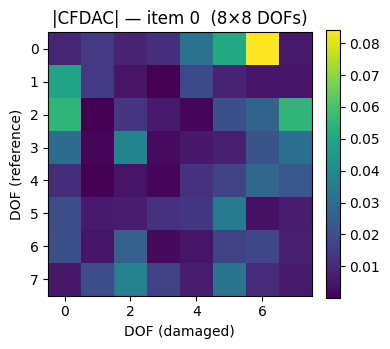

In [12]:
# Visualise one CFDAC matrix
mat = np.abs(cfdac.measurements[0][()][:, :, 0, 0])
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(mat, cmap="viridis")
ax.set(title="|CFDAC| — item 0  (8×8 DOFs)", xlabel="DOF (damaged)", ylabel="DOF (reference)")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 8 · Provenance — recover the original FRFs from any indicator

Because every indicator collection embeds its reference and damaged sources,
we can read back the exact `(reference_i, damaged_i)` FRF pair that produced
any item — even if the original FRF files have been deleted.

In [13]:
ref_back = cfdac.get_reference_data("reference", 0)   # (n_freq, 8, 1) — the source FRF
dmg_back = cfdac.get_reference_data("damaged",   0)
print(f"reference FRF for cfdac item 0: shape={ref_back.shape}, dtype={ref_back.dtype}")
print(f"damaged   FRF for cfdac item 0: shape={dmg_back.shape}, dtype={dmg_back.dtype}")
# These match the originals
print(f"reference equal to ref_chain[0]?  {np.allclose(ref_back, ref_chain.measurements[0][()])}")
print(f"damaged   equal to dmg_chain[0]?  {np.allclose(dmg_back, dmg_chain.measurements[0][()])}")

reference FRF for cfdac item 0: shape=(64, 8, 1), dtype=complex64
damaged   FRF for cfdac item 0: shape=(64, 8, 1), dtype=complex64
reference equal to ref_chain[0]?  True
damaged   equal to dmg_chain[0]?  True


## 9 · PyTorch handoff across all dimensionalities

`HDF5Dataset` reads `/measurements/{name}/data` directly, skipping the
collection-level `_axes` group. Item rank is whatever the writer used —
0-D collections yield rank-2 items, 1-D yield rank-3, 2-D yield rank-4 — so
a `DataLoader` over a `cfdac_collection` produces 4-D tensors out of the box.

In [14]:
import torch
from torch.utils.data import DataLoader

# 1-D round-trip (FRF)
many.torch_dataset()
ds_1d = many.dataset
xb, yb = next(iter(DataLoader(ds_1d, batch_size=2)))
print(f"frf            DataLoader batch: x.shape={tuple(xb.shape)}  y={yb.tolist()}")

# 2-D round-trip (CFDAC)
cfdac.torch_dataset()
ds_2d = cfdac.dataset
xb, yb = next(iter(DataLoader(ds_2d, batch_size=2)))
print(f"cfdac          DataLoader batch: x.shape={tuple(xb.shape)}  y={yb.tolist()}")

# 0-D round-trip (SCI)
sci.torch_dataset()
ds_0d = sci.dataset
xb, yb = next(iter(DataLoader(ds_0d, batch_size=2)))
print(f"sci            DataLoader batch: x.shape={tuple(xb.shape)}  y={yb.tolist()}")

frf            DataLoader batch: x.shape=(2, 64, 4, 1)  y=[1, 0]
cfdac          DataLoader batch: x.shape=(2, 8, 8, 1, 1)  y=[1, 2]
sci            DataLoader batch: x.shape=(2, 1, 1)  y=[1, 2]


## 10 · Cleanup

In [15]:
import shutil
shutil.rmtree(WORK, ignore_errors=True)
print("Removed working directory.")

Removed working directory.
